# From snapshots to snowfall totals

The event notebook showed the satellite and the gauge rarely mean the same
thing at any single instant. Accumulation sidesteps that: treat each overpass
as a random sample of the region's snowfall rate, average the samples, and
multiply by time. This is the method behind every CloudSat snowfall
climatology — and, as far as the published record shows (checked against the
2025 EarthCARE workshop summary and the AMT/ACP special issues), **nobody has
yet published a snowfall accumulation estimate from EarthCARE**. This is a
first attempt, on one station and three months.

**The estimator** (Palerme et al. 2014, *The Cryosphere* 8, 1577 — validated
against ERA-Interim over Antarctica at 171 vs 163 mm w.e./yr; applied to the
Arctic by Edel et al. 2020; station-scale variant in King et al. 2020):

$$ S \;=\; T \cdot \frac{1}{N}\sum_{i=1}^{N} \bar{R}_i, \qquad
   \bar{R}_i = \text{mean rate of ALL usable profiles of overpass } i $$

Two properties matter:
- **Zeros are included.** $\left(\bar{R}_i\right)$ is an *unconditional* mean — a
  cloud-free overpass contributes 0, and that is what makes mean × time an
  accumulation rather than an intensity.
- **Each overpass counts once**, whether it crossed the middle of the circle
  (hundreds of profiles) or clipped its edge (a handful) — overpasses are the
  independent samples; profiles within one overpass are not.

Screening as in the event notebook: `convergence_status == 0`, rates
< 20 mm/h, snowfall at the 1000 m AGL reference level; gauge side uses
snow-phase precip (T ≤ +1.5 °C).

**Caveats carried throughout:**
1. *The gauge is a lower bound.* Aasiaat's shielded automatic gauge at ~5 m/s
   wind catches roughly 60–90% of true snowfall (WMO-SPICE transfer
   functions, Kochendorfer et al. 2017), and winds during snow here average
   6.9 m/s. No correction is applied — by design, for now.
2. *The satellite rate is an extrapolation* from 1 km AGL across the radar's
   blind zone.
3. *~14 overpasses per month is a small sample.* Souverijns et al. (2018)
   found 30–40% seasonal sampling uncertainty at CloudSat-like revisit rates;
   Scarsi et al. (2025) show this class of nadir sampling only beats climate
   variability at multi-degree or seasonal scales. EarthCARE also always
   samples at the same two local times (~14:00/02:00).

## 1 · Build the monthly estimates

One row per overpass and radius: the unconditional mean rate $\bar{R}_i$.
Three ways of turning those into a monthly total are shown side by side —
they differ only in how the month's profiles are averaged before × hours:

- **Palerme** (the estimator used throughout): mean of the per-overpass means,
  $S = T \cdot \frac{1}{N}\sum_i \bar{R}_i$. Each overpass counts once,
  whether it contributed 500 profiles or 5 — overpasses are the independent
  samples.
- **King** (King et al. 2020 variant): mean of the per-overpass *medians*.
  Meant as an outlier guard, but snowfall along a track is zero-inflated
  (most profiles are clear air), so an overpass's median is 0 unless more
  than half of its profiles are snowing. It behaves as a
  "majority-of-track-snowing" estimator and is biased low for patchy snow —
  it never exceeds Palerme in the table.
- **Pooled**: every profile of the month within the radius lumped into one
  sample, one plain mean. This is *profile-weighted*: a centre-crossing
  overpass with hundreds of profiles outweighs an edge-clipping one with a
  handful. It ignores that profiles within an overpass are not independent
  (so it has no legitimate bootstrap), but it is the intuitive "average of
  everything we saw". Palerme and pooled agree when overpasses contribute
  similar profile counts and diverge when they don't (March at ≤100 km:
  46 vs 23 mm) — that gap is an honest measure of estimator uncertainty at
  N ≈ 14 overpasses per month.

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, "../src")
import eo_reader as eo
from gauges import load_gauge_snow
from study_config import OUTLIER_MMHR, STATIONS
from validation import bootstrap_ci, hours_in_month

# --- notebook-specific settings ---
AASIAAT = STATIONS["aasiaat"]
RADII_KM = [30, 50, 100]        # collocation radii to compare
RNG = np.random.default_rng(422000)

# --- load both sides: Disko-box EO subset and the snow-phase hourly gauge ---
subset = eo.open_subset("../data/eo_subset/")
station, precip_snow = load_gauge_snow(AASIAAT)

# --- satellite side: per-profile arrays and the usability screen ---
profile_time = pd.to_datetime(subset["time"].values)
profile_granule = subset["granule"].values
dist_station = subset[AASIAAT["dist_col"]].values
snowfall_1km = subset["snowfall_mmhr_1000m"].values
usable = ((subset["convergence_status"].values == 0)
          & np.isfinite(snowfall_1km) & (snowfall_1km < OUTLIER_MMHR))

# --- one unconditional mean (and median) rate per overpass and radius ---
overpass_rows = []
for granule_id in sorted(set(profile_granule[usable & (dist_station <= max(RADII_KM))])):
    in_granule = usable & (profile_granule == granule_id)
    t_overpass = pd.Series(profile_time[in_granule]).mean()
    for radius in RADII_KM:
        in_radius = in_granule & (dist_station <= radius)
        if not in_radius.any():
            continue
        overpass_rows.append({
            "granule": granule_id,
            "month": t_overpass.to_period("M").strftime("%Y-%m"),
            "radius_km": radius,
            "n_profiles": int(in_radius.sum()),
            "mean_rate_mmhr": float(snowfall_1km[in_radius].mean()),   # zeros included
            "median_rate_mmhr": float(np.median(snowfall_1km[in_radius])),
        })
overpass_rates = pd.DataFrame(overpass_rows)


# --- monthly satellite totals: Palerme (mean of overpass means) and King
#     (mean of overpass medians), each scaled by the hours in the month ---
monthly_table = (overpass_rates
                 .groupby(["month", "radius_km"])
                 .agg(overpasses=("granule", "nunique"),
                      palerme_rate=("mean_rate_mmhr", "mean"),
                      king_rate=("median_rate_mmhr", "mean"))
                 .reset_index())
monthly_table["hours"] = monthly_table["month"].map(hours_in_month)
monthly_table["sat_mm_palerme"] = monthly_table["palerme_rate"] * monthly_table["hours"]
monthly_table["sat_mm_king"] = monthly_table["king_rate"] * monthly_table["hours"]

# --- monthly gauge totals (snow-phase, uncorrected) ---
gauge_monthly_mm = precip_snow.resample("ME").sum()
gauge_monthly_mm.index = gauge_monthly_mm.index.to_period("M").strftime("%Y-%m")
monthly_table["gauge_mm"] = monthly_table["month"].map(gauge_monthly_mm)

# --- pooled-profile mean for comparison (the naive version: every profile
#     of the month weighted equally, so long overpasses dominate) ---
profile_month = pd.Series(profile_time).dt.to_period("M").astype(str).values
pooled_mm = []
for (month, radius), _ in overpass_rates.groupby(["month", "radius_km"]):
    in_month_radius = usable & (dist_station <= radius) & (profile_month == month)
    pooled_mm.append(float(snowfall_1km[in_month_radius].mean()) * hours_in_month(month))
monthly_table["sat_mm_pooled"] = pooled_mm

show_cols = ["month", "radius_km", "overpasses", "sat_mm_palerme", "sat_mm_king",
             "sat_mm_pooled", "gauge_mm"]
print("Palerme (mean of overpass means) vs King (mean of overpass medians) "
      "vs pooled profiles, mm/month:")
monthly_table[show_cols].round(1)

Palerme (mean of overpass means) vs King (mean of overpass medians) vs pooled profiles, mm/month:


,month,radius_km,overpasses,sat_mm_palerme,sat_mm_king,sat_mm_pooled,gauge_mm
0,2025-01,30,3,3.6,1.3,3.6,23.9
1,2025-01,50,7,4.9,0.9,7.0,23.9
2,2025-01,100,14,81.6,65.8,32.9,23.9
3,2025-02,30,5,0.2,0.1,0.1,17.1
4,2025-02,50,7,0.9,0.4,1.0,17.1
5,2025-02,100,13,28.8,16.8,23.6,17.1
6,2025-03,30,4,0.3,0.0,0.2,20.5
7,2025-03,50,6,1.0,0.1,1.2,20.5
8,2025-03,100,15,46.0,32.3,22.7,20.5
9,2025-04,30,5,5.7,5.0,8.5,4.3


## 2 · Monthly totals with sampling uncertainty

Bootstrap over overpasses (10,000 draws of the ~14 monthly
$\bar{R}_i$ with replacement, 10–90th percentile band — the same
percentiles Souverijns et al. report). The ≤30 km whiskers are the point:
with 4–5 samples a month, the estimate is whatever the last big overpass
said.

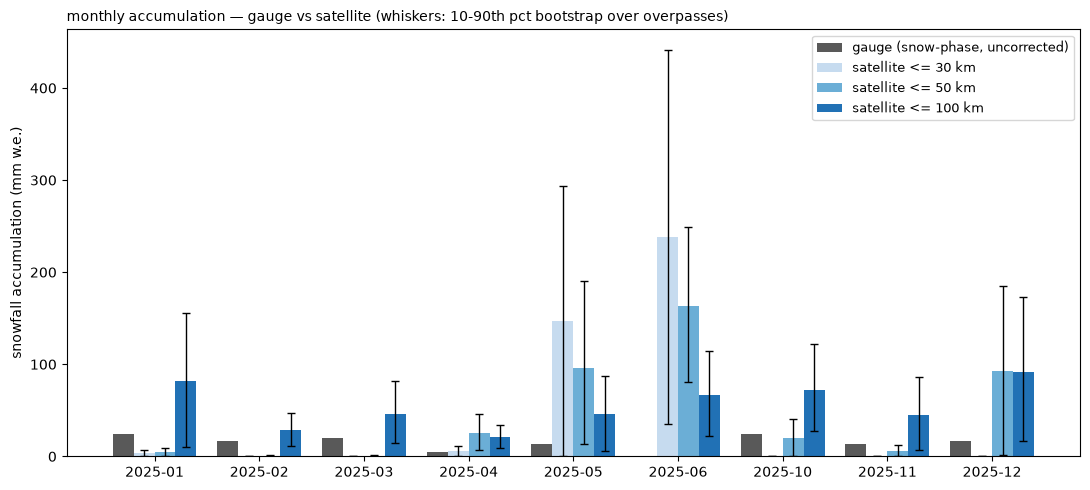

In [2]:
# --- bootstrap band for every (month, radius) Palerme estimate ---
ci_lo, ci_hi = [], []
for _, row in monthly_table.iterrows():
    month_rates = overpass_rates[(overpass_rates.month == row["month"])
                                 & (overpass_rates.radius_km == row["radius_km"])]
    lo, hi = bootstrap_ci(month_rates["mean_rate_mmhr"].values, row["hours"], RNG)
    ci_lo.append(lo); ci_hi.append(hi)
monthly_table["ci10_mm"], monthly_table["ci90_mm"] = ci_lo, ci_hi

# --- plotting monthly totals: gauge bar + one satellite bar per radius ---
months = sorted(monthly_table["month"].unique())
bar_x = np.arange(len(months))
bar_width = 0.2

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(bar_x - 1.5 * bar_width, [gauge_monthly_mm[m] for m in months], bar_width,
       color="0.35", label="gauge (snow-phase, uncorrected)")
palette = {30: "#c6dbef", 50: "#6baed6", 100: "#2171b5"}
for k, radius in enumerate(RADII_KM):
    radius_rows = monthly_table[monthly_table.radius_km == radius].set_index("month")
    sat_mm = [radius_rows.loc[m, "sat_mm_palerme"] if m in radius_rows.index else np.nan
              for m in months]
    lo = [radius_rows.loc[m, "ci10_mm"] if m in radius_rows.index else np.nan
          for m in months]
    hi = [radius_rows.loc[m, "ci90_mm"] if m in radius_rows.index else np.nan
          for m in months]
    err_bars = [np.array(sat_mm) - np.array(lo), np.array(hi) - np.array(sat_mm)]
    ax.bar(bar_x + (k - 0.5) * bar_width, sat_mm, bar_width, color=palette[radius],
           label=f"satellite <= {radius} km")
    ax.errorbar(bar_x + (k - 0.5) * bar_width, sat_mm, yerr=err_bars, fmt="none",
                ecolor="k", elinewidth=1, capsize=3)
ax.set_xticks(bar_x, months)
ax.set_ylabel("snowfall accumulation (mm w.e.)")
ax.set_title("monthly accumulation — gauge vs satellite (whiskers: "
             "10-90th pct bootstrap over overpasses)", loc="left", fontsize=10)
ax.legend(fontsize=9)
fig.savefig("../figures/eo_dmi_accumulation_monthly.png", dpi=130,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

## 3 · Seasonal rollup and convergence

Left: the season total per radius against the gauge. Right: the running
Palerme estimate as overpasses accumulate — how long it takes each radius to
stop swinging. A curve that is still jumping by the last overpass has not
converged, and its total is a coin flip.

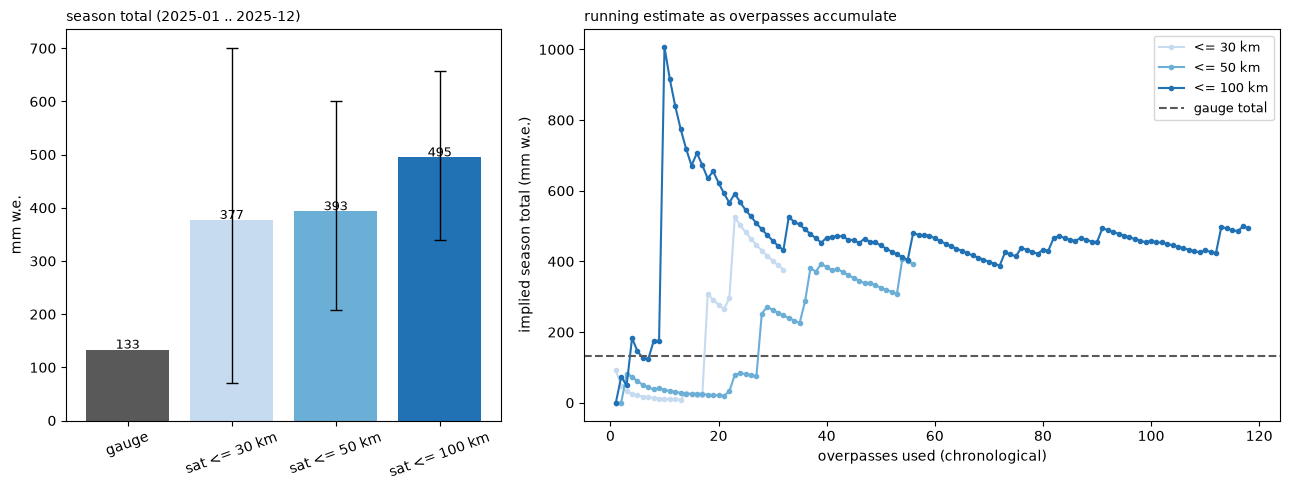

<=  30 km: 32 overpasses ->  377.0 mm  (10-90th pct: 67.6 .. 697.0)
<=  50 km: 56 overpasses ->  393.4 mm  (10-90th pct: 202.5 .. 596.1)
<= 100 km: 118 overpasses ->  494.7 mm  (10-90th pct: 339.2 .. 662.0)
gauge (snow-phase, uncorrected): 133.2 mm


In [3]:
# --- season totals over all months in the table ---
season_hours = float(sum(hours_in_month(m) for m in months))
season_gauge_mm = float(sum(gauge_monthly_mm[m] for m in months))

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [1, 1.6]})

# --- left: season total, gauge vs satellite per radius, with bootstrap whiskers ---
bar_labels, totals, ci_los, ci_his = ["gauge"], [season_gauge_mm], [np.nan], [np.nan]
for radius in RADII_KM:
    radius_rows = overpass_rates[overpass_rates.radius_km == radius]
    season_total_mm = float(radius_rows["mean_rate_mmhr"].mean() * season_hours)
    lo, hi = bootstrap_ci(radius_rows["mean_rate_mmhr"].values, season_hours, RNG)
    bar_labels.append(f"sat <= {radius} km")
    totals.append(season_total_mm); ci_los.append(lo); ci_his.append(hi)
colors = ["0.35"] + [palette[r] for r in RADII_KM]
bars = axes[0].bar(bar_labels, totals, color=colors)
err_bars = [np.array(totals) - np.array(ci_los), np.array(ci_his) - np.array(totals)]
axes[0].errorbar(bar_labels, totals, yerr=err_bars, fmt="none", ecolor="k",
                 elinewidth=1, capsize=4)
for bar, total in zip(bars, totals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, total + 2, f"{total:.0f}",
                 ha="center", fontsize=9)
axes[0].set_ylabel("mm w.e.")
axes[0].set_title(f"season total ({months[0]} .. {months[-1]})",
                  loc="left", fontsize=10)
axes[0].tick_params(axis="x", rotation=20)

# --- right: convergence -- the running season estimate as overpasses accrue ---
for radius in RADII_KM:
    radius_rows = (overpass_rates[overpass_rates.radius_km == radius]
                   .sort_values("granule"))
    running_total_mm = radius_rows["mean_rate_mmhr"].expanding().mean() * season_hours
    axes[1].plot(np.arange(1, len(running_total_mm) + 1), running_total_mm, "-o",
                 ms=3, color=palette[radius], label=f"<= {radius} km")
axes[1].axhline(season_gauge_mm, color="0.35", lw=1.5, ls="--",
                label="gauge total")
axes[1].set_xlabel("overpasses used (chronological)")
axes[1].set_ylabel("implied season total (mm w.e.)")
axes[1].set_title("running estimate as overpasses accumulate",
                  loc="left", fontsize=10)
axes[1].legend(fontsize=9)
fig.savefig("../figures/eo_dmi_accumulation_seasonal.png", dpi=130,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- the same season numbers as text ---
for radius in RADII_KM:
    radius_rows = overpass_rates[overpass_rates.radius_km == radius]
    season_total_mm = radius_rows["mean_rate_mmhr"].mean() * season_hours
    lo, hi = bootstrap_ci(radius_rows["mean_rate_mmhr"].values, season_hours, RNG)
    print(f"<= {radius:>3} km: {len(radius_rows):>2} overpasses -> "
          f"{season_total_mm:6.1f} mm  (10-90th pct: {lo:.1f} .. {hi:.1f})")
print(f"gauge (snow-phase, uncorrected): {season_gauge_mm:.1f} mm")

## 4 · Takeaways

- **The ≤100 km radius is the only defensible accumulation estimator at this
  sample size** — its bootstrap band, while wide, is finite and stable in the
  running-estimate plot; ≤30 km is a lottery ticket at 4–5 overpasses/month,
  exactly as Scarsi et al. (2025) predict for nadir sampling at sub-degree
  scales.
- **Compare the satellite–gauge gap against the whiskers before calling it a
  bias.** Where the gauge sits inside (or near) the 10–90% band, sampling
  alone explains the difference. And remember the gauge itself likely reads
  ~60–90% of true snowfall in these winds — the two effects pull in opposite
  directions.
- **Palerme's equal-overpass weighting and the pooled-profile mean disagree
  where it matters** — March at ≤100 km: 46 vs 23 mm. The culprit is
  edge-clipping overpasses: a track that cuts the circle's rim contributes a
  handful of profiles, and if those happened to be snowing, equal weighting
  doubles them up. The literature's implicit answer is scale (hundreds of
  overpasses per cell in Palerme's Antarctica); at N ≈ 14/month the choice of
  estimator is itself a ~2× uncertainty. Both are reported for that reason —
  and the bootstrap, built on overpasses, at least makes the sampling part of
  that visible.
- **Next steps in order of value:** more months (the full 2025 subset exists
  on SharePoint — every additional month narrows the whiskers by roughly
  √N); an undercatch-corrected gauge band; then the climate model as the
  third leg of the triangle.